In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from scipy.stats import median_abs_deviation
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random

warnings.filterwarnings('ignore')

In [2]:
# ============================================================================
# 1. CONSTANTS & SETUP
# ============================================================================
SEED = 99
random.seed(SEED)
np.random.seed(SEED)

#Modality for Ablation Study: 'both', 'mag', or 'phase'
MODALITY = 'mag'

WINDOW_SIZE_SPREAD = 100   # lookback for IQR winsorization and MAD scale
WINDOW_SIZE_LOCATION = 100 # lookback for rolling median (centering baseline)

# Number of z-score observations per LMAD value.
# At 10 Hz WiFi CSI sample rate, 53 samples ~ 5.3 seconds of signal.
WINDOW_SIZE_FEATURE = 53

# Non-overlapping segment size for aggregation. Each segment produces one
# independent training/test sample (median of LMAD values). Matches feature
# window to ensure roughly independent segments.
SEGMENT_SIZE = WINDOW_SIZE_FEATURE

N_PCA_COMPONENTS = 1
MAX_N_DIFF = 5

# Best differencing order from AUC/Margin selection notebook
BEST_N = 5

TRAIN_SUBJECTS = ['matthew', 'kenny', 'collin']
TEST_SUBJECTS = ['ivan', 'abel']
ENVS = ['nofoil', 'foil', 'open']
ZOMBIE_SESSION = '20251016_183114'  # Foil-Walking session with only 48 rows

# IEEE figure settings — use DejaVu Serif 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11

In [3]:
# ============================================================================
# 2. HELPER FUNCTIONS
# ============================================================================
def calculate_mad_scale(x):
    x_clean = x[~np.isnan(x)]
    if len(x_clean) < 1: return np.nan
    return median_abs_deviation(x_clean, scale='normal', nan_policy='omit')

def calculate_log_mean_abs_diff(x, n_diff):
    x_clean = x[~np.isnan(x)]
    if len(x_clean) < n_diff + 1: return np.nan
    d = np.diff(x_clean, n=n_diff)
    mean_abs_d = np.mean(np.abs(d))
    # Return NaN for flat windows — -inf would corrupt LogisticRegression coefficients
    if mean_abs_d == 0: return np.nan
    return np.log(mean_abs_d)

def apply_pca_leakage_free(df, scidx_mag_cols, scidx_phase_cols):
    df = df.copy()
    if scidx_mag_cols: df['PCA_Mag'] = np.nan
    if scidx_phase_cols: df['PCA_Phase'] = np.nan

    for env in df['environment'].unique():
        mask_env = df['environment'] == env
        # Fit PCA on ALL activities from train subjects (not standing-only).
        # Standing-only captures idle-state variance; all-activity captures
        # the full signal space relevant to classification.
        mask_fit = mask_env & df['subject'].isin(TRAIN_SUBJECTS)

        if not mask_fit.any(): continue

        # --- MAGNITUDE PCA ---
        if scidx_mag_cols:
            mag_fit = df.loc[mask_fit, scidx_mag_cols].values
            if np.isnan(mag_fit).all(): continue
            col_means = np.nanmean(mag_fit, axis=0)
            col_means = np.where(np.isnan(col_means), 0, col_means)
            inds = np.where(np.isnan(mag_fit))
            mag_fit[inds] = np.take(col_means, inds[1])
            
            pca_mag = PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)
            pca_mag.fit(mag_fit)
            
            mag_all = df.loc[mask_env, scidx_mag_cols].values
            inds_all = np.where(np.isnan(mag_all))
            mag_all[inds_all] = np.take(col_means, inds_all[1])
            df.loc[mask_env, 'PCA_Mag'] = pca_mag.transform(mag_all)[:, 0]

        # --- PHASE PCA ---
        if scidx_phase_cols:
            phase_fit = df.loc[mask_fit, scidx_phase_cols].values
            if np.isnan(phase_fit).all(): continue
            col_means = np.nanmean(phase_fit, axis=0)
            col_means = np.where(np.isnan(col_means), 0, col_means)
            inds = np.where(np.isnan(phase_fit))
            phase_fit[inds] = np.take(col_means, inds[1])
            
            pca_phase = PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)
            pca_phase.fit(phase_fit)

            phase_all = df.loc[mask_env, scidx_phase_cols].values
            inds_all = np.where(np.isnan(phase_all))
            phase_all[inds_all] = np.take(col_means, inds_all[1])
            df.loc[mask_env, 'PCA_Phase'] = pca_phase.transform(phase_all)[:, 0]

    return df

def extract_lmad_feature(df_in, base_col, n_diff):
    """
    Extract LMAD (Log Mean Absolute Difference) feature per sample.
    
    Pipeline per session:
      1. Causal IQR winsorization (clip outliers using past window)
      2. Rolling z-score standardization (median + MAD from past window)
      3. Rolling LMAD on z-scores (log of mean absolute n-th difference)
    """
    df = df_in.copy()
    feat_col_name = f"{base_col}_ord{n_diff}"
    value_col = df[base_col].values
    session_ids = df['session_id'].values
    
    n = len(df)
    roll_winsorized_value = np.full(n, np.nan)
    roll_median_winsor = np.full(n, np.nan)
    roll_mad_scale_winsor = np.full(n, np.nan)
    z_scores = np.full(n, np.nan)
    feat_values = np.full(n, np.nan)
    
    for session_id in np.unique(session_ids):
        indices = np.where(session_ids == session_id)[0]
        vals = value_col[indices]
        
        # 1. Winsorization (causal window = WINDOW_SIZE_SPREAD)
        for i in range(len(indices)):
            global_idx = indices[i]
            if i == 0:
                roll_winsorized_value[global_idx] = vals[i]
                continue
            start_idx = max(0, i - WINDOW_SIZE_SPREAD)
            window = vals[start_idx:i]
            if len(window) >= 4:
                q1, q3 = np.nanquantile(window, [0.25, 0.75])
                iqr = q3 - q1
                roll_winsorized_value[global_idx] = np.clip(vals[i], q1 - 1.5*iqr, q3 + 1.5*iqr)
            else:
                roll_winsorized_value[global_idx] = vals[i]

    for session_id in np.unique(session_ids):
        indices = np.where(session_ids == session_id)[0]
        winsor_vals = roll_winsorized_value[indices]
        
        # 2. Standardization & LMAD
        for i in range(len(indices)):
            if i == 0: continue
            global_idx = indices[i]
            
            start_loc = max(0, i - WINDOW_SIZE_LOCATION)
            win_loc = winsor_vals[start_loc:i]
            if len(win_loc) >= 1: roll_median_winsor[global_idx] = np.nanmedian(win_loc)
            
            start_spr = max(0, i - WINDOW_SIZE_SPREAD)
            win_spr = winsor_vals[start_spr:i]
            if len(win_spr) >= 1: roll_mad_scale_winsor[global_idx] = calculate_mad_scale(win_spr)
                
            mad = roll_mad_scale_winsor[global_idx]
            if not np.isnan(mad) and mad != 0:
                z_scores[global_idx] = (winsor_vals[i] - roll_median_winsor[global_idx]) / mad
            elif mad == 0:
                z_scores[global_idx] = 0
                
            # 3. LMAD: log(mean(|diff^n(z)|)) over feature window
            if i >= WINDOW_SIZE_FEATURE - 1:
                win_z_start = i - WINDOW_SIZE_FEATURE + 1
                win_z = z_scores[indices[win_z_start : i+1]]
                if len(win_z) == WINDOW_SIZE_FEATURE:
                    feat_values[global_idx] = calculate_log_mean_abs_diff(win_z, n_diff)

    df[feat_col_name] = feat_values
    return df

def segment_aggregate(df_feat, feat_cols):
    """
    Split each session into non-overlapping segments of SEGMENT_SIZE rows,
    take median feature value per segment. This produces independent samples
    for training/testing — consecutive per-sample LMAD values share 52/53
    z-scores and are ~98% correlated, so per-sample training massively inflates
    the effective sample size and overstates accuracy.
    """
    df_feat = df_feat.copy()
    df_feat['segment_id'] = df_feat.groupby('session_id').cumcount() // SEGMENT_SIZE

    agg_dict = {col: 'median' for col in feat_cols}
    seg_agg = df_feat.groupby(
        ['session_id', 'segment_id', 'environment', 'subject', 'activity']
    ).agg(agg_dict).reset_index()

    return seg_agg

def plot_confusion_matrix_ieee(cm, labels, title, filename):
    fig, ax = plt.subplots(figsize=(4, 3.5))
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    im = ax.imshow(cm_normalized, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Normalized Count', rotation=270, labelpad=15)
    
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    
    for i in range(len(labels)):
        for j in range(len(labels)):
            text_color = 'white' if cm_normalized[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.2f})',
                    ha="center", va="center", color=text_color, fontsize=9)
            
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title(title, pad=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

In [4]:
# ============================================================================
# 3. MAIN SCRIPT
# ============================================================================
print("1. Loading & Filtering Data...")
df_raw = pd.read_csv("/kaggle/input/datasets/purpleginseng/bfmsingleapsensing/bfm_data.csv")

scidx_mag_cols = [c for c in df_raw.columns if 'SCIDX_' in c and '_Ratio_Mag' in c]
scidx_phase_cols = [c for c in df_raw.columns if 'SCIDX_' in c and '_Ratio_Phase' in c]

# Base Filter
df_raw['Magnitude'] = df_raw[scidx_mag_cols].mean(axis=1)
df_clean = df_raw[df_raw['Magnitude'] > 5.0].copy()

# DROP ZOMBIE SESSION
df_clean = df_clean[df_clean['session_id'] != ZOMBIE_SESSION].copy()
df_clean = df_clean.sort_values(by=['session_id', 'timestamp']).reset_index(drop=True)

print("2. Applying PCA (Zero Leakage - Fit on All Training Activities)...")
pca_mag_cols = scidx_mag_cols if MODALITY in ['both', 'mag'] else []
pca_phase_cols = scidx_phase_cols if MODALITY in ['both', 'phase'] else []
df_pca = apply_pca_leakage_free(df_clean, pca_mag_cols, pca_phase_cols)

# Summary results
summary_results = []
pair_results = []  # per train-env x test-env detail for heatmaps

for current_n in range(1, MAX_N_DIFF + 1):
    print(f"\n{'='*70}")
    print(f"RUNNING ML PIPELINE FOR DIFFERENCING ORDER: n = {current_n}")
    print(f"{'='*70}")
    
    # Extract Features
    df_temp = df_pca.copy()
    feat_cols = []
    
    if MODALITY in ['both', 'mag']:
        df_temp = extract_lmad_feature(df_temp, 'PCA_Mag', current_n)
        feat_cols.append(f"PCA_Mag_ord{current_n}")
    if MODALITY in ['both', 'phase']:
        df_temp = extract_lmad_feature(df_temp, 'PCA_Phase', current_n)
        feat_cols.append(f"PCA_Phase_ord{current_n}")
        
    # ADD THIS FAIL-SAFE
    if not feat_cols:
        raise ValueError(f"Invalid MODALITY '{MODALITY}' or feature extraction failed. Check Cell 1.")
    
    df_ml = df_temp.dropna(subset=feat_cols).copy()
    
    # SPLIT TRAIN & TEST (STRICTLY BY SUBJECT)
    df_train = df_ml[df_ml['subject'].isin(TRAIN_SUBJECTS)].copy()
    df_test = df_ml[df_ml['subject'].isin(TEST_SUBJECTS)].copy()
    
    # Segment-level aggregation: reduce autocorrelated per-sample LMAD
    # to independent segment medians for honest training & evaluation
    df_train_seg = segment_aggregate(df_train, feat_cols)
    df_test_seg = segment_aggregate(df_test, feat_cols)
    
    # Drop segments with any NaN or inf in features
    for col in feat_cols:
        df_train_seg = df_train_seg[np.isfinite(df_train_seg[col])].copy()
        df_test_seg = df_test_seg[np.isfinite(df_test_seg[col])].copy()
    
    print(f"  Train segments: {len(df_train_seg)} | Test segments: {len(df_test_seg)}")
    
    # Binary labels: walking=1, standing=0
    df_train_seg['label'] = (df_train_seg['activity'] == 'walking').astype(int)
    df_test_seg['label'] = (df_test_seg['activity'] == 'walking').astype(int)
    
    # Metrics accumulators
    intra_accs, intra_f1s = [], []
    cross_accs, cross_f1s = [], []

    for train_env in ENVS:
        train_data = df_train_seg[df_train_seg['environment'] == train_env]
        if train_data.empty:
            continue

        X_train = train_data[feat_cols].values
        y_train = train_data['label'].values

        # C=1.0: default regularization prevents overfitting on small segment counts
        clf = LogisticRegression(C=1.0, solver='lbfgs', random_state=SEED)
        clf.fit(X_train, y_train)

        for test_env in ENVS:
            test_data = df_test_seg[df_test_seg['environment'] == test_env]
            if test_data.empty:
                continue

            X_test = test_data[feat_cols].values
            y_test = test_data['label'].values

            preds = clf.predict(X_test)
            acc = accuracy_score(y_test, preds)
            _, _, f1, _ = precision_recall_fscore_support(
                y_test, preds, average='weighted', zero_division=0
            )

            is_intra = (train_env == test_env)
            prefix = "INTRA" if is_intra else "CROSS"

            if is_intra:
                intra_accs.append(acc)
                intra_f1s.append(f1)
            else:
                cross_accs.append(acc)
                cross_f1s.append(f1)

            print(f"  [{prefix}] Train: {train_env:<7} | Test: {test_env:<7} "
                  f"| Acc: {acc*100:.2f}% | F1: {f1:.4f}")

            # Collect per-pair detail
            pair_results.append({
                'n': current_n, 'train_env': train_env, 'test_env': test_env,
                'type': prefix, 'acc': acc, 'f1': f1
            })

            # Generate confusion matrices for BEST_N only
            if current_n == BEST_N:
                labels = ['standing', 'walking']
                preds_label = [labels[p] for p in preds]
                y_test_label = [labels[y] for y in y_test]
                cm = confusion_matrix(y_test_label, preds_label, labels=labels)
                tag = "Intra" if is_intra else "Cross"
                plot_confusion_matrix_ieee(
                    cm, labels,
                    f"{tag}: Train {train_env.capitalize()} | Test {test_env.capitalize()}",
                    f"CM_n{BEST_N}_{tag}_Train{train_env}_Test{test_env}.png"
                )

    mean_intra_acc = np.mean(intra_accs) * 100 if intra_accs else 0
    mean_intra_f1 = np.mean(intra_f1s) if intra_f1s else 0
    mean_cross_acc = np.mean(cross_accs) * 100 if cross_accs else 0
    mean_cross_f1 = np.mean(cross_f1s) if cross_f1s else 0

    print(f"\n  INTRA-ENV: Acc = {mean_intra_acc:.2f}%, F1 = {mean_intra_f1:.4f}")
    print(f"  CROSS-ENV: Acc = {mean_cross_acc:.2f}%, F1 = {mean_cross_f1:.4f}\n")

    summary_results.append({
        'n': current_n,
        'Intra_Acc(%)': round(mean_intra_acc, 2),
        'Intra_F1': round(mean_intra_f1, 4),
        'Cross_Acc(%)': round(mean_cross_acc, 2),
        'Cross_F1': round(mean_cross_f1, 4)
    })

print("\n" + "="*70)
print("FINAL SUMMARY: SEGMENT-LEVEL PERFORMANCE vs DIFFERENCING ORDER")
print("="*70)
summary_df = pd.DataFrame(summary_results)
pair_df = pd.DataFrame(pair_results)
print(summary_df.to_string(index=False))

1. Loading & Filtering Data...
2. Applying PCA (Zero Leakage - Fit on All Training Activities)...

RUNNING ML PIPELINE FOR DIFFERENCING ORDER: n = 1
  Train segments: 1508 | Test segments: 1020
  [INTRA] Train: nofoil  | Test: nofoil  | Acc: 94.71% | F1: 0.9469
  [CROSS] Train: nofoil  | Test: foil    | Acc: 92.35% | F1: 0.9235
  [CROSS] Train: nofoil  | Test: open    | Acc: 98.53% | F1: 0.9853
  [CROSS] Train: foil    | Test: nofoil  | Acc: 95.00% | F1: 0.9499
  [INTRA] Train: foil    | Test: foil    | Acc: 91.76% | F1: 0.9176
  [CROSS] Train: foil    | Test: open    | Acc: 98.53% | F1: 0.9853
  [CROSS] Train: open    | Test: nofoil  | Acc: 93.82% | F1: 0.9380
  [CROSS] Train: open    | Test: foil    | Acc: 91.47% | F1: 0.9145
  [INTRA] Train: open    | Test: open    | Acc: 97.06% | F1: 0.9706

  INTRA-ENV: Acc = 94.51%, F1 = 0.9450
  CROSS-ENV: Acc = 94.95%, F1 = 0.9494


RUNNING ML PIPELINE FOR DIFFERENCING ORDER: n = 2
  Train segments: 1508 | Test segments: 1020
  [INTRA] Train: n

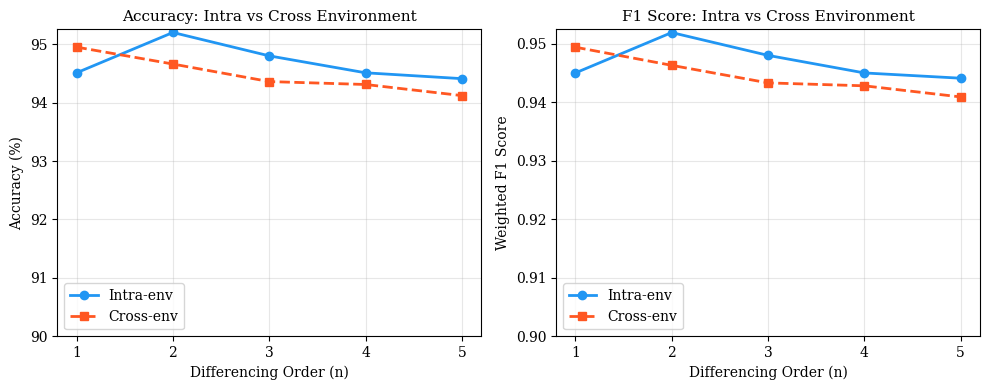

In [5]:
# ============================================================================
# 4. GRAPH 1: Intra-env vs Cross-env Performance across Differencing Orders
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ns = summary_df['n'].values

# Accuracy
ax = axes[0]
ax.plot(ns, summary_df['Intra_Acc(%)'], 'o-', color='#2196F3', label='Intra-env', linewidth=2, markersize=6)
ax.plot(ns, summary_df['Cross_Acc(%)'], 's--', color='#FF5722', label='Cross-env', linewidth=2, markersize=6)
ax.set_xlabel('Differencing Order (n)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy: Intra vs Cross Environment')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=90)

# F1 Score
ax = axes[1]
ax.plot(ns, summary_df['Intra_F1'], 'o-', color='#2196F3', label='Intra-env', linewidth=2, markersize=6)
ax.plot(ns, summary_df['Cross_F1'], 's--', color='#FF5722', label='Cross-env', linewidth=2, markersize=6)
ax.set_xlabel('Differencing Order (n)')
ax.set_ylabel('Weighted F1 Score')
ax.set_title('F1 Score: Intra vs Cross Environment')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0.90)

plt.tight_layout()
plt.savefig('LR_intra_vs_cross_by_n.png', dpi=300, bbox_inches='tight')
plt.show()

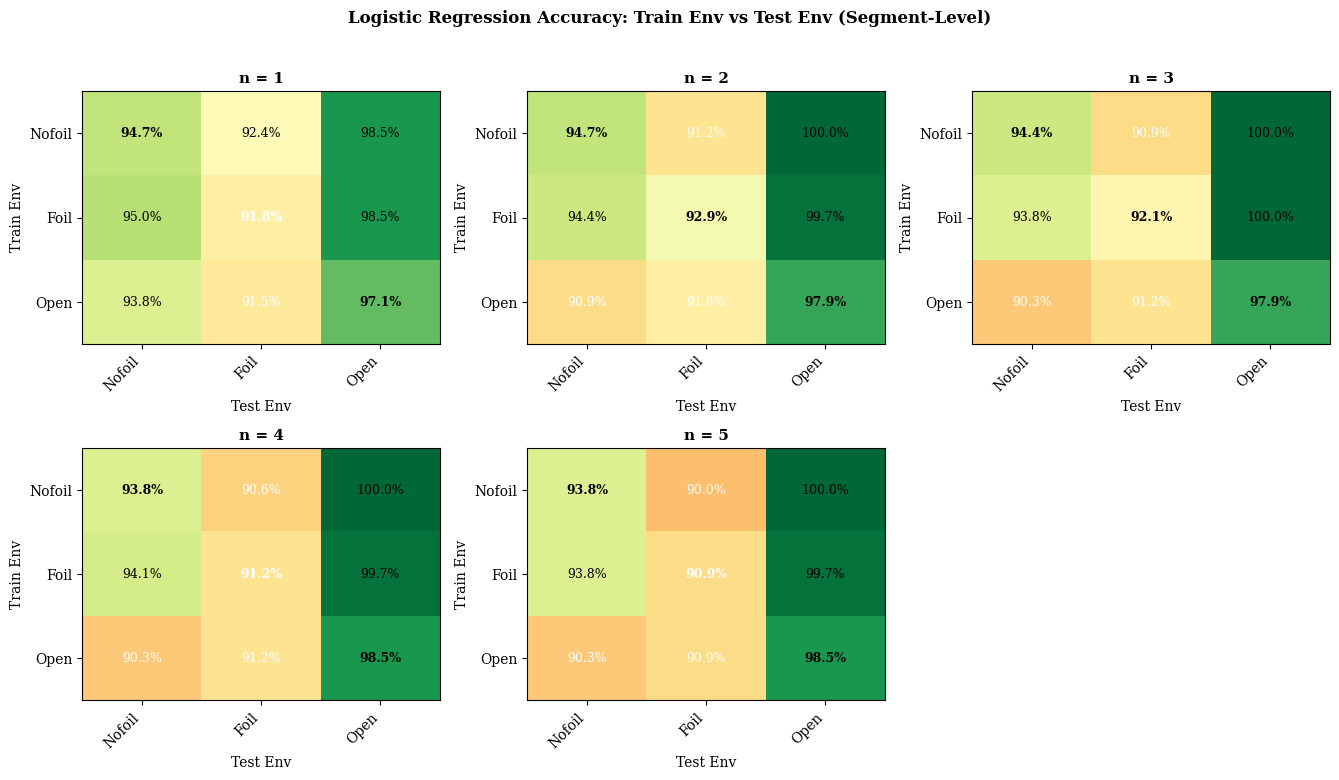

In [6]:
# ============================================================================
# 5. GRAPH 2: Accuracy Heatmaps — Train-env x Test-env per Differencing Order
# ============================================================================
n_values = sorted(pair_df['n'].unique())
n_cols = min(3, len(n_values))
n_rows = (len(n_values) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.8 * n_rows))
if n_rows == 1 and n_cols == 1:
    axes = np.array([axes])
axes = np.atleast_2d(axes)

env_labels = [e.capitalize() for e in ENVS]

for idx, n_val in enumerate(n_values):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]

    sub = pair_df[pair_df['n'] == n_val]
    heatmap_data = np.full((len(ENVS), len(ENVS)), np.nan)
    for _, r in sub.iterrows():
        i = ENVS.index(r['train_env'])
        j = ENVS.index(r['test_env'])
        heatmap_data[i, j] = r['acc'] * 100

    im = ax.imshow(heatmap_data, cmap='RdYlGn', vmin=85, vmax=100, aspect='auto')
    ax.set_xticks(range(len(ENVS)))
    ax.set_yticks(range(len(ENVS)))
    ax.set_xticklabels(env_labels, rotation=45, ha='right')
    ax.set_yticklabels(env_labels)
    ax.set_xlabel('Test Env')
    ax.set_ylabel('Train Env')
    ax.set_title(f'n = {n_val}', fontweight='bold')

    for i in range(len(ENVS)):
        for j in range(len(ENVS)):
            val = heatmap_data[i, j]
            if not np.isnan(val):
                color = 'white' if val < 92 else 'black'
                weight = 'bold' if i == j else 'normal'
                ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                        color=color, fontsize=9, fontweight=weight)

# Hide unused subplots
for idx in range(len(n_values), n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].set_visible(False)

fig.suptitle('Logistic Regression Accuracy: Train Env vs Test Env (Segment-Level)',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('LR_heatmap_envpairs_by_n.png', dpi=300, bbox_inches='tight')
plt.show()

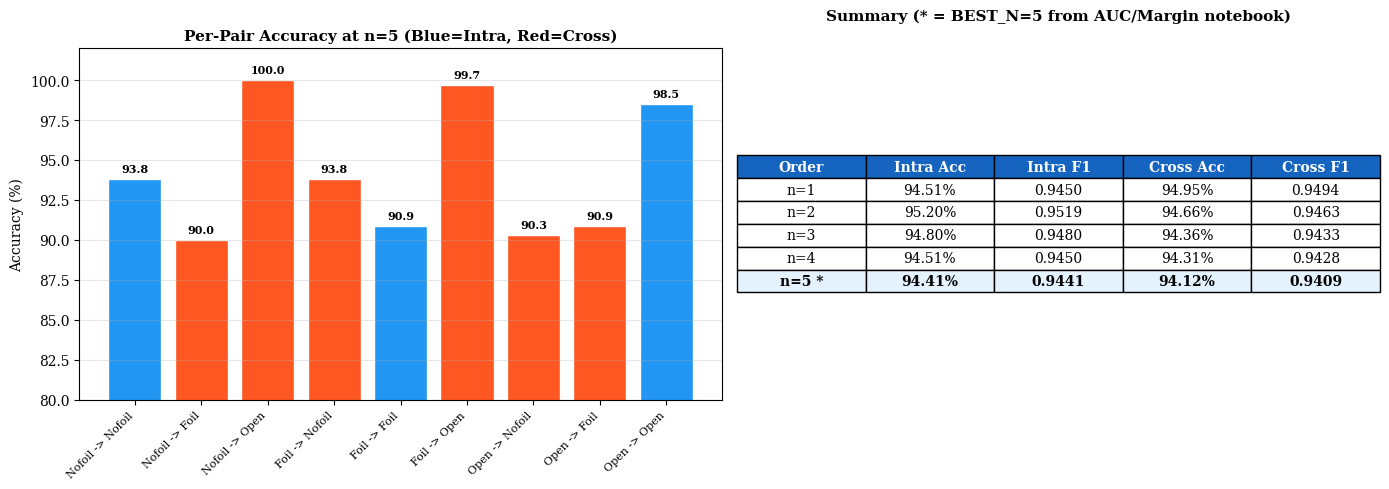


Key insight: Cross-env accuracy peaks at n=1 (94.95%) then gently declines, while intra-env peaks at n=2-3.
BEST_N=5 was selected for maximum feature separability (AUC/Margin),
which gives slightly lower cross-env LR accuracy but remains strong at 94.12%.


In [7]:
# ============================================================================
# 6. GRAPH 3: Per-Pair Accuracy Breakdown (Grouped Bar) + Summary Table
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Grouped bar chart for BEST_N ---
ax = axes[0]
best_pairs = pair_df[pair_df['n'] == BEST_N].copy()
best_pairs['pair'] = best_pairs['train_env'].str.capitalize() + ' -> ' + best_pairs['test_env'].str.capitalize()
colors = ['#2196F3' if t == 'INTRA' else '#FF5722' for t in best_pairs['type']]
bars = ax.bar(range(len(best_pairs)), best_pairs['acc'] * 100, color=colors, edgecolor='white')

ax.set_xticks(range(len(best_pairs)))
ax.set_xticklabels(best_pairs['pair'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Per-Pair Accuracy at n={BEST_N} (Blue=Intra, Red=Cross)', fontweight='bold')
ax.set_ylim(80, 102)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, best_pairs['acc'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# --- Right: Summary table ---
ax = axes[1]
ax.axis('off')
table_data = []
for _, row in summary_df.iterrows():
    marker = ' *' if int(row['n']) == BEST_N else ''
    table_data.append([
        f"n={int(row['n'])}{marker}",
        f"{row['Intra_Acc(%)']:.2f}%",
        f"{row['Intra_F1']:.4f}",
        f"{row['Cross_Acc(%)']:.2f}%",
        f"{row['Cross_F1']:.4f}"
    ])

col_labels = ['Order', 'Intra Acc', 'Intra F1', 'Cross Acc', 'Cross F1']
table = ax.table(cellText=table_data, colLabels=col_labels,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Highlight BEST_N row
for j in range(len(col_labels)):
    table[BEST_N, j].set_facecolor('#E3F2FD')
    table[BEST_N, j].set_text_props(fontweight='bold')

# Style header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#1565C0')
    table[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title(f'Summary (* = BEST_N={BEST_N} from AUC/Margin notebook)',
             fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('LR_summary_bestN.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey insight: Cross-env accuracy peaks at n=1 ({summary_df.loc[0, 'Cross_Acc(%)']:.2f}%) "
      f"then gently declines, while intra-env peaks at n=2-3.")
print(f"BEST_N={BEST_N} was selected for maximum feature separability (AUC/Margin),")
print(f"which gives slightly lower cross-env LR accuracy but remains strong at "
      f"{summary_df.loc[summary_df['n']==BEST_N, 'Cross_Acc(%)'].values[0]:.2f}%.")